# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV24"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv24')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv24/lv24-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV24,gene_band
0,KCNK7,5.501678,11q13.1
1,KRT1,5.084971,12q13.13
2,ACER1,4.931350,19p13.3
3,ASPRV1,4.901245,2p13.3
4,CDHR1,4.253085,10q23.1
5,CTNNBIP1,3.859810,1p36.22
6,CAPNS2,3.379442,16q12.2
7,ELOVL3,3.331303,10q24.32
8,KLC3,3.326713,19q13.32
9,DSP,3.114874,6p24.3


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-04-22 19:37:46,937 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-04-22 19:37:46,937 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR
130,PID_DELTANP63PATHWAY,24,0.783682,0.001222,0.00906


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP035864, SRP035988, SRP050971, SRP026042, SRP057087, SRP021891, SRP014146, SRP052740, SRP043085, SRP065812, SRP033135, SRP009251, SRP060416, SRP010678, SRP042620, SRP017575, SRP055569, SRP042161, SRP058773, SRP006575, SRP065445, SRP016583, SRP052856, SRP014320, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (23 != 24)
  warnings.warn(


In [12]:
lv_data.shape

(3566, 40)

In [13]:
lv_data.head()

treatment tissue tissue type patient patient id gender  \
project   run                                                                 
SRP035864 SRR1145042       UVB   skin         NaN     NaN        NaN    NaN   
          SRR1145043       UVB   skin         NaN     NaN        NaN    NaN   
          SRR1145044       UVB   skin         NaN     NaN        NaN    NaN   
          SRR1145045       UVB   skin         NaN     NaN        NaN    NaN   
          SRR1145046       UVB   skin         NaN     NaN        NaN    NaN   

                      age tissue/treatment id group subjects  ... prognosis  \
project   run                                                 ...             
SRP035864 SRR1145042  NaN                 NaN   NaN      NaN  ...       NaN   
          SRR1145043  NaN                 NaN   NaN      NaN  ...       NaN   
          SRR1145044  NaN                 NaN   NaN      NaN  ...       NaN   
          SRR1145045  NaN                 NaN   NaN      NaN  ...       NaN   
          SRR1145046  NaN                 NaN   NaN      NaN  ...       NaN   

                     cell line subtype well number  \
project   run                                        
SRP035864 SRR1145042       NaN     NaN         NaN   
          SRR1145043       NaN     NaN         NaN   
          SRR1145044       NaN     NaN         NaN   
          SRR1145045       NaN     NaN         NaN   
          SRR1145046       NaN     NaN         NaN   

                     reprogramming time point (day) developmental stage  \
project   run                                                             
SRP035864 SRR1145042                            NaN                 NaN   
          SRR1145043                            NaN                 NaN   
          SRR1145044                            NaN                 NaN   
          SRR1145045                            NaN                 NaN   
          SRR1145046                            NaN                 NaN   

                     disease status diagnosis growth conditions      LV24  
project   run                                                              
SRP035864 SRR1145042            NaN       NaN               NaN  0.526173  
          SRR1145043            NaN       NaN               NaN  0.442285  
          SRR1145044            NaN       NaN               NaN  0.395936  
          SRR1145045            NaN       NaN               NaN  0.316462  
          SRR1145046            NaN       NaN               NaN  0.349480  

[5 rows x 40 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

patient                                    0.132075
treatment                                  0.128854
group                                      0.126801
gender                                     0.124774
age                                        0.113823
tissue/treatment id                        0.113823
tissue type                                0.113683
tissue                                     0.080025
patient id                                 0.036987
response to smoothened (smo) inhibitors    0.035944
day of differentiation                     0.030759
subject status                             0.028648
mapki sensitivity                          0.024978
mapki treatment                            0.024978
parasite                                   0.021734
clinical form                              0.021734
age group                                  0.019295
time point                                 0.017572
growth conditions                          0.016845
diagnosis   

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue type    0.113683
tissue         0.080025
cell type      0.003662
cell line      0.002098
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "tissue type",
    "tissue",
    "cell type",
    "cell line",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

tissue type  \
project   run                           
SRP035864 SRR1145049              NaN   
SRP035988 SRR1146248      normal skin   
SRP050971 SRR1698137      normal skin   
SRP035864 SRR1145047              NaN   
SRP026042 SRR901225               NaN   
SRP050971 SRR1698172      normal skin   
          SRR1698173      normal skin   
SRP057087 SRR1970416              NaN   
          SRR1970420              NaN   
SRP035988 SRR1146249      normal skin   
          SRR1146146      normal skin   
SRP035864 SRR1145050              NaN   
SRP050971 SRR1698141      normal skin   
SRP035864 SRR1145048              NaN   
SRP050971 SRR1698134      normal skin   
          SRR1698135      normal skin   
          SRR1698136      normal skin   
SRP021891 SRR836000               NaN   
SRP050971 SRR1698167  Uninvolved skin   
SRP026042 SRR901185               NaN   
          SRR901169               NaN   
SRP035988 SRR1146246      normal skin   
SRP057087 SRR1970418              NaN   
SRP026042 SRR1382100              NaN   
          SRR901193               NaN   

                                                        tissue cell type  \
project   run                                                              
SRP035864 SRR1145049                                      skin       NaN   
SRP035988 SRR1146248                                       NaN       NaN   
SRP050971 SRR1698137                                       NaN       NaN   
SRP035864 SRR1145047                                      skin       NaN   
SRP026042 SRR901225                                    Healthy       NaN   
SRP050971 SRR1698172                                       NaN       NaN   
          SRR1698173                                       NaN       NaN   
SRP057087 SRR1970416                                       NaN       NaN   
          SRR1970420                                       NaN       NaN   
SRP035988 SRR1146249                                       NaN       NaN   
          SRR1146146                                       NaN       NaN   
SRP035864 SRR1145050                                      skin       NaN   
SRP050971 SRR1698141                                       NaN       NaN   
SRP035864 SRR1145048                                      skin       NaN   
SRP050971 SRR1698134                                       NaN       NaN   
          SRR1698135                                       NaN       NaN   
          SRR1698136                                       NaN       NaN   
SRP021891 SRR836000   skin (epidermal suction blister samples)       NaN   
SRP050971 SRR1698167                                       NaN       NaN   
SRP026042 SRR901185                                  Nonlesion       NaN   
          SRR901169                                  Nonlesion       NaN   
SRP035988 SRR1146246                                       NaN       NaN   
SRP057087 SRR1970418                                       NaN       NaN   
SRP026042 SRR1382100                                 Nonlesion       NaN   
          SRR901193                                  Nonlesion       NaN   

                     cell line      LV24  
project   run                             
SRP035864 SRR1145049       NaN  1.519073  
SRP035988 SRR1146248       NaN  1.404224  
SRP050971 SRR1698137       NaN  1.387150  
SRP035864 SRR1145047       NaN  1.380989  
SRP026042 SRR901225        NaN  1.376663  
SRP050971 SRR1698172       NaN  1.372574  
          SRR1698173       NaN  1.372336  
SRP057087 SRR1970416       NaN  1.337396  
          SRR1970420       NaN  1.328275  
SRP035988 SRR1146249       NaN  1.314768  
          SRR1146146       NaN  1.303178  
SRP035864 SRR1145050       NaN  1.297412  
SRP050971 SRR1698141       NaN  1.291499  
SRP035864 SRR1145048       NaN  1.274616  
SRP050971 SRR1698134       NaN  1.267954  
          SRR1698135       NaN  1.264631  
          SRR1698136       NaN  1.260249  
SRP021891 SRR836000        NaN  1.238848  
SRP05

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

tissue type  \
project   run                                   
SRP035988 SRR1146244              normal skin   
SRP026042 SRR901161                       NaN   
          SRR901229                       NaN   
SRP035988 SRR1146191              normal skin   
          SRR1146243              normal skin   
          SRR1146238              normal skin   
          SRR1146131              normal skin   
SRP057087 SRR1970398                      NaN   
          SRR1970410                      NaN   
SRP050971 SRR1698164          Uninvolved skin   
SRP057087 SRR1970412                      NaN   
SRP050971 SRR1698168          Uninvolved skin   
SRP035988 SRR1146186              normal skin   
SRP050971 SRR1698166          Uninvolved skin   
          SRR1698158          Uninvolved skin   
          SRR1698150          Uninvolved skin   
          SRR1698156          Uninvolved skin   
SRP035988 SRR1146171              normal skin   
          SRR1146230              normal skin   
          SRR1146247              normal skin   
SRP021891 SRR835999                       NaN   
SRP026042 SRR901201                       NaN   
SRP035988 SRR1146096              normal skin   
SRP050971 SRR1698157          Uninvolved skin   
SRP035988 SRR1146217  lesional psoriatic skin   

                                                        tissue cell type  \
project   run                                                              
SRP035988 SRR1146244                                       NaN       NaN   
SRP026042 SRR901161                                  Nonlesion       NaN   
          SRR901229                                    Healthy       NaN   
SRP035988 SRR1146191                                       NaN       NaN   
          SRR1146243                                       NaN       NaN   
          SRR1146238                                       NaN       NaN   
          SRR1146131                                       NaN       NaN   
SRP057087 SRR1970398                                       NaN       NaN   
          SRR1970410                                       NaN       NaN   
SRP050971 SRR1698164                                       NaN       NaN   
SRP057087 SRR1970412                                       NaN       NaN   
SRP050971 SRR1698168                                       NaN       NaN   
SRP035988 SRR1146186                                       NaN       NaN   
SRP050971 SRR1698166                                       NaN       NaN   
          SRR1698158                                       NaN       NaN   
          SRR1698150                                       NaN       NaN   
          SRR1698156                                       NaN       NaN   
SRP035988 SRR1146171                                       NaN       NaN   
          SRR1146230                                       NaN       NaN   
          SRR1146247                                       NaN       NaN   
SRP021891 SRR835999   skin (epidermal suction blister samples)       NaN   
SRP026042 SRR901201                                  Nonlesion       NaN   
SRP035988 SRR1146096                                       NaN       NaN   
SRP050971 SRR1698157                                       NaN       NaN   
SRP035988 SRR1146217                                       NaN       NaN   

                     cell line      LV24  
project   run                             
SRP035988 SRR1146244       NaN  1.201108  
SRP026042 SRR901161        NaN  1.199438  
          SRR901229        NaN  1.190844  
SRP035988 SRR1146191       NaN  1.184670  
          SRR1146243       NaN  1.179124  
          SRR1146238       NaN  1.164314  
          SRR1146131       NaN  1.157228  
SRP057087 SRR1970398       NaN  1.156435  
          SRR1970410       NaN  1.149749  
SRP050971 SRR1698164       NaN  1.148879  
SRP057087 SRR1970412       NaN  1.145804  
SRP050971 SRR1698168       NaN  1.144609  
SRP035988 SRR1146186       NaN  1.143780  
SRP050971 SR

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP035864"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

treatment tissue      LV24
project   run                                  
SRP035864 SRR1145049   Control   skin  1.519073
          SRR1145047   Control   skin  1.380989
          SRR1145050   Control   skin  1.297412
          SRR1145048   Control   skin  1.274616
          SRR1145042       UVB   skin  0.526173
          SRR1145043       UVB   skin  0.442285
          SRR1145044       UVB   skin  0.395936
          SRR1145046       UVB   skin  0.349480
          SRR1145045       UVB   skin  0.316462

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [22]:
SELECTED_ATTRIBUTES = [
    "tissue type",
    "tissue",
    "cell type",
    "cell line",
]

## Get a single attribute with "cell type/tissue" information

In [23]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [24]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [25]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [26]:
plot_data.head(20)

tissue type      LV24
project   run                                                           
SRP035864 SRR1145049                                      skin  1.519073
SRP035988 SRR1146248                               normal skin  1.404224
SRP050971 SRR1698137                               normal skin  1.387150
SRP035864 SRR1145047                                      skin  1.380989
SRP026042 SRR901225                                    Healthy  1.376663
SRP050971 SRR1698172                               normal skin  1.372574
          SRR1698173                               normal skin  1.372336
SRP057087 SRR1970416                           NOT CATEGORIZED  1.337396
          SRR1970420                           NOT CATEGORIZED  1.328275
SRP035988 SRR1146249                               normal skin  1.314768
          SRR1146146                               normal skin  1.303178
SRP035864 SRR1145050                                      skin  1.297412
SRP050971 SRR1698141                               normal skin  1.291499
SRP035864 SRR1145048                                      skin  1.274616
SRP050971 SRR1698134                               normal skin  1.267954
          SRR1698135                               normal skin  1.264631
          SRR1698136                               normal skin  1.260249
SRP021891 SRR836000   skin (epidermal suction blister samples)  1.238848
SRP050971 SRR1698167                           Uninvolved skin  1.230030
SRP026042 SRR901185                                  Nonlesion  1.218949

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [27]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [28]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [29]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [30]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [31]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [32]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [33]:
N_TOP_ATTRS = 10

In [34]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [35]:
len(attr_order)

10

In [36]:
attr_order[:5]

['skin',
 'normal skin',
 'Healthy',
 'NOT CATEGORIZED',
 'skin (epidermal suction blister samples)']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

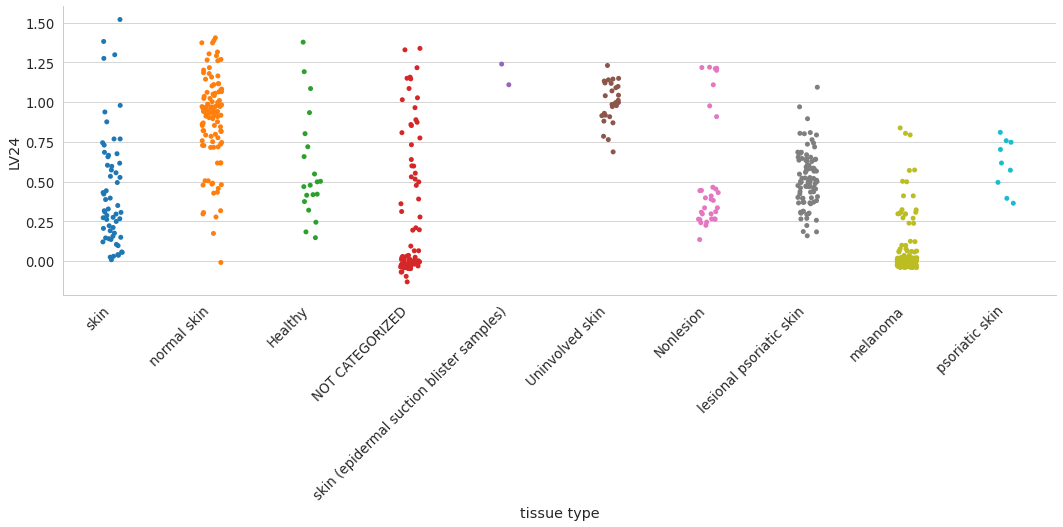

In [37]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

#     plt.savefig(
#         OUTPUT_CELL_TYPE_FILEPATH,
#         bbox_inches="tight",
#         facecolor="white",
#     )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("NOT CAT")
    ]
    display(_tmp.head(20))

tissue type      LV24
project   run                                  
SRP057087 SRR1970416  NOT CATEGORIZED  1.337396
          SRR1970420  NOT CATEGORIZED  1.328275
          SRR1970418  NOT CATEGORIZED  1.215959
          SRR1970398  NOT CATEGORIZED  1.156435
          SRR1970410  NOT CATEGORIZED  1.149749
          SRR1970412  NOT CATEGORIZED  1.145804
          SRR1970414  NOT CATEGORIZED  1.085125
          SRR1970402  NOT CATEGORIZED  1.026727
          SRR1970400  NOT CATEGORIZED  1.014584
          SRR1970406  NOT CATEGORIZED  0.964631
          SRR1970394  NOT CATEGORIZED  0.888795
          SRR1970411  NOT CATEGORIZED  0.872706
          SRR1970404  NOT CATEGORIZED  0.858728
          SRR1970396  NOT CATEGORIZED  0.852233
          SRR1970408  NOT CATEGORIZED  0.807428
          SRR1970417  NOT CATEGORIZED  0.774097
          SRR1970419  NOT CATEGORIZED  0.731714
          SRR1970405  NOT CATEGORIZED  0.638534
          SRR1970399  NOT CATEGORIZED  0.598748
          SRR1970395  NOT CATEGORIZED  0.597570

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP057087, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP057087"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

patient  gender group      LV24
project   run                                       
SRP057087 SRR1970416      12  female    PN  1.337396
          SRR1970420      14  female    PN  1.328275
          SRR1970418      13  female    PN  1.215959
          SRR1970398       3    male    PN  1.156435
          SRR1970410       9    male    PN  1.149749
          SRR1970412      10    male    PN  1.145804
          SRR1970414      11  female    PN  1.085125
          SRR1970402       5    male    PN  1.026727
          SRR1970400       4  female    PN  1.014584
          SRR1970406       7    male    PN  0.964631
          SRR1970394       1    male    PN  0.888795
          SRR1970411      10    male    PP  0.872706
          SRR1970404       6  female    PN  0.858728
          SRR1970396       2    male    PN  0.852233
          SRR1970408       8    male    PN  0.807428
          SRR1970417      13  female    PP  0.774097
          SRR1970419      14  female    PP  0.731714
          SRR1970405       7    male    PP  0.638534
          SRR1970399       4  female    PP  0.598748
          SRR1970395       2    male    PP  0.597570
          SRR1970401       5    male    PP  0.552676
          SRR1970393       1    male    PP  0.529576
          SRR1970415      12  female    PP  0.515398
          SRR1970397       3    male    PP  0.497741
          SRR1970407       8    male    PP  0.476089
          SRR1970413      11  female    PP  0.390206
          SRR1970403       6  female    PP  0.311670
          SRR1970409       9    male    PP  0.194421

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.